# Min-Variance + XGBoost Tilt - 10-Day Rolling EW FF5 Risk Model

This notebook builds a rolling 10-trading-day rebalance portfolio:

1. Load the shared price data with `portfolio_toolkit`.
2. Build a Fama-French 5-factor covariance model at each rebalance date.
3. Estimate factor betas with exponentially weighted least squares so recent observations matter more.
4. Shrink factor covariance and residual covariance with Ledoit-Wolf where possible.
5. Train an XGBoost model to predict 10-day cross-sectional outperformance.
6. Slightly tilt rolling minimum-variance weights toward the XGBoost signal.
7. Validate, backtest, write artifacts, and log to MLflow.

The minimum-variance optimizer is the backbone. XGBoost only gets a small weight budget through `TILT_ALPHA`.

## 0. Bootstrap And Dependencies

This cell locates the repository root from either a local notebook session or Colab-style working directory, then installs the toolkit and the extra notebook-only packages.

In [1]:
import os
import sys
import subprocess
from pathlib import Path


def is_repo_root(path: Path) -> bool:
    return (path / 'pyproject.toml').exists() and (path / 'src' / 'portfolio_toolkit').exists()


def find_repo_root() -> Path:
    candidates = []
    if 'repo_root' in globals():
        candidates.append(Path(repo_root).expanduser())
    if os.environ.get('PWD'):
        candidates.append(Path(os.environ['PWD']).expanduser())
    candidates.append(Path.cwd())
    for candidate in candidates:
        try:
            resolved = candidate.resolve()
        except FileNotFoundError:
            continue
        for path in [resolved, *resolved.parents]:
            if is_repo_root(path):
                return path
    raise RuntimeError('Could not locate repository root. Set repo_root manually and rerun this cell.')


repo_root = find_repo_root()
os.chdir(repo_root)
src_path = repo_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

print('repo_root =', repo_root)
print('python =', sys.executable)
print('cwd =', Path.cwd())

# The repo dev install provides the toolkit. The other packages are notebook-local dependencies.
subprocess.check_call([
    sys.executable,
    '-m',
    'pip',
    'install',
    '-q',
    '-e',
    str(repo_root) + '[dev]',
    'xgboost',
    'cvxpy',
    'pandas-datareader',
    'scikit-learn',
    'yfinance',
])

print('Install complete')

repo_root = /Users/eamonnavin/Portfolio-Optimization-Lib
python = /usr/local/bin/python3
cwd = /Users/eamonnavin/Portfolio-Optimization-Lib
Install complete


## 1. Imports And Configuration

All tunable parameters are kept in one place. `PREDICTION_HORIZON_DAYS` and `REBALANCE_EVERY_DAYS` are both set to 10 as requested.

In [2]:
import json
import warnings
warnings.filterwarnings('ignore')

import cvxpy as cp
import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import pandas_datareader.data as pdr
import xgboost as xgb
import yfinance as yf
import portfolio_toolkit.backtest as _bt_module
from sklearn.covariance import LedoitWolf
from sklearn.metrics import accuracy_score, log_loss

from portfolio_toolkit import (
    PortfolioWeights,
    backtest_weights,
    build_features,
    build_metrics,
    get_dataset_spec,
    init_mlflow,
    load_prices,
    log_backtest,
    log_model_submission,
    log_portfolio,
    make_forward_return_target,
    slice_split,
    split_dates,
    start_run,
    validate_weights_frame,
    write_backtest_artifacts,
)

DATASET_NAME = 'shared_set_1'
MODEL_NAME = 'Eamon_Run4'
MINVAR_MODEL_NAME = 'Eamon_Run4'

PREDICTION_HORIZON_DAYS = 10
REBALANCE_EVERY_DAYS = 10
FF_WINDOW = 252
EW_HALFLIFE = 63
TILT_ALPHA = 0.02
MIN_WEIGHT = 0.0
MAX_WEIGHT = 0.15
MIN_FACTOR_OBS = 126
RANDOM_STATE = 42

OUTPUT_DIR = repo_root / 'runs' / 'minvar_wk3'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
IV_CACHE_PATH = OUTPUT_DIR / 'current_iv_snapshot.csv'
MODEL_ARTIFACT_PATH = OUTPUT_DIR / f'{MODEL_NAME}.json'

FACTOR_COLS = ['Mkt-RF', 'SMB', 'HML', 'RMW', 'CMA']

BASE_TILT_FEATURE_NAMES = [
    'vol_5d',
    'vol_10d',
    'vol_20d',
    'vol_60d',
    'downside_vol_20d',
    'upside_vol_20d',
    'atr_14',
    'volume_change_1d',
    'volume_change_5d',
    'volume_change_20d',
    'volume_zscore_20d',
    'volume_zscore_60d',
    'dollar_volume_ratio_20d',
    'price_to_sma_10d',
    'price_to_sma_20d',
    'price_to_sma_50d',
    'price_to_sma_200d',
]
VOL_OF_VOL_FEATURE_NAMES = ['vol_of_vol_10d', 'vol_of_vol_20d', 'vol_of_vol_60d']
IV_FEATURE_NAMES = ['current_iv', 'current_iv_missing']
TILT_FEATURE_NAMES = BASE_TILT_FEATURE_NAMES + VOL_OF_VOL_FEATURE_NAMES + IV_FEATURE_NAMES

assert PREDICTION_HORIZON_DAYS == 10
assert REBALANCE_EVERY_DAYS == 10

print('Dataset:', DATASET_NAME)
print('Prediction horizon:', PREDICTION_HORIZON_DAYS)
print('Rebalance cadence:', REBALANCE_EVERY_DAYS)
print('FF window:', FF_WINDOW)
print('EW halflife:', EW_HALFLIFE)
print('Tilt alpha:', TILT_ALPHA)
print('Feature count:', len(TILT_FEATURE_NAMES))

Dataset: shared_set_1
Prediction horizon: 10
Rebalance cadence: 10
FF window: 252
EW halflife: 63
Tilt alpha: 0.02
Feature count: 22


## 1a. Notebook-Local Backtest Alignment Patch

This cell keeps the backtest row-normalization fix inside the notebook.

In [3]:
import portfolio_toolkit.backtest as _bt_module
import pandas as pd


def _fixed_align_weights_to_prices(weights, price_index):
    aligned_rows = []
    aligned_index = []
    for date_value, row in weights.sort_index().iterrows():
        requested = pd.Timestamp(date_value)
        position = price_index.searchsorted(requested, side="left")
        if position >= len(price_index):
            continue
        aligned_rows.append(row)
        aligned_index.append(pd.Timestamp(price_index[position]))
    if not aligned_rows:
        raise ValueError("no weight rows align to the available trading calendar")
    aligned = pd.DataFrame(aligned_rows, index=pd.DatetimeIndex(aligned_index))
    aligned.index.name = "date"
    aligned = aligned.groupby(level=0).last()
    aligned = aligned.div(aligned.sum(axis=1), axis=0)
    return _bt_module.validate_weights_frame(aligned)


_bt_module._align_weights_to_prices = _fixed_align_weights_to_prices
print("Patch applied")

Patch applied


## 2. Load Shared Prices And Splits

The shared dataset and split helpers keep the run comparable with the rest of the repository. The benchmark ticker is excluded from the investable universe.

In [4]:
spec = get_dataset_spec(DATASET_NAME, repo_root=repo_root)
splits = split_dates(DATASET_NAME, repo_root=repo_root)
prices = load_prices(DATASET_NAME, repo_root=repo_root)

train_start, train_end = splits['train']
val_start, val_end = splits['val']
test_start, test_end = splits['test']

adj_close = prices.pivot(index='date', columns='ticker', values='adj_close').sort_index()
adj_close.index = pd.to_datetime(adj_close.index)
returns_wide = adj_close.pct_change().dropna(how='all')

portfolio_tickers = [ticker for ticker in spec.tickers if ticker in adj_close.columns]
benchmark_ticker = spec.benchmark_ticker

print('Dataset display name:', spec.name)
print('Benchmark:', benchmark_ticker)
print('Configured tickers:', len(spec.tickers))
print('Tickers with price columns:', len(portfolio_tickers))
print('Date range:', prices['date'].min(), '->', prices['date'].max())
print('Splits:', splits)
display(prices.head())

Dataset display name: sp500_full_universe
Benchmark: SPY
Configured tickers: 503
Tickers with price columns: 502
Date range: 2014-01-02 00:00:00 -> 2025-12-31 00:00:00
Splits: {'train': (Timestamp('2014-01-02 00:00:00'), Timestamp('2019-12-31 00:00:00')), 'val': (Timestamp('2020-01-02 00:00:00'), Timestamp('2021-12-31 00:00:00')), 'test': (Timestamp('2022-01-03 00:00:00'), Timestamp('2025-12-31 00:00:00'))}


,date,ticker,open,high,low,close,adj_close,volume
0,2014-01-02,A,40.844063,40.844063,40.164520,40.207439,36.303501,2678848
1,2014-01-03,A,40.336197,41.022888,40.243206,40.715309,36.762058,2609647
2,2014-01-06,A,41.058655,41.273247,40.457798,40.515022,36.581223,2484665
3,2014-01-07,A,40.736767,41.223175,40.722462,41.094421,37.104351,2045554
4,2014-01-08,A,41.008583,41.874107,40.894135,41.766811,37.711468,3717981


## 3. Current Implied Volatility Feature

Warning: the repository only stores historical OHLCV data. This notebook uses current yfinance option-chain implied volatility as requested. That value is not historical point-in-time IV, so it is not a clean historical backtest signal. It is cached in the run folder and repeated as a static ticker-level feature across all dates.

In [5]:
def _nearest_atm_iv(option_frame: pd.DataFrame, spot: float) -> float:
    if option_frame.empty or not np.isfinite(spot):
        return np.nan
    frame = option_frame.loc[:, ['strike', 'impliedVolatility']].copy()
    frame['impliedVolatility'] = pd.to_numeric(frame['impliedVolatility'], errors='coerce')
    frame = frame.dropna(subset=['strike', 'impliedVolatility'])
    if frame.empty:
        return np.nan
    idx = (frame['strike'] - spot).abs().idxmin()
    return float(frame.loc[idx, 'impliedVolatility'])


def fetch_current_iv_snapshot(tickers, latest_prices, cache_path: Path, refresh: bool = False) -> pd.DataFrame:
    if cache_path.exists() and not refresh:
        cached = pd.read_csv(cache_path)
        cached['ticker'] = cached['ticker'].astype(str).str.upper()
        if 'current_iv' not in cached.columns:
            median_iv = cached['current_iv_raw'].median(skipna=True) if 'current_iv_raw' in cached.columns else np.nan
            if not np.isfinite(median_iv):
                median_iv = 0.25
            cached['current_iv_missing'] = cached.get('current_iv_raw', pd.Series(np.nan, index=cached.index)).isna().astype(float)
            cached['current_iv'] = cached.get('current_iv_raw', pd.Series(np.nan, index=cached.index)).fillna(median_iv)
        return cached

    rows = []
    for idx, ticker in enumerate(tickers, start=1):
        spot = float(latest_prices.get(ticker, np.nan))
        current_iv = np.nan
        expiration = None
        try:
            yf_ticker = yf.Ticker(ticker)
            expirations = list(yf_ticker.options)
            if expirations:
                expiration = expirations[0]
                chain = yf_ticker.option_chain(expiration)
                call_iv = _nearest_atm_iv(chain.calls, spot)
                put_iv = _nearest_atm_iv(chain.puts, spot)
                current_iv = float(np.nanmean([call_iv, put_iv]))
        except Exception as exc:
            print(f'IV fetch failed for {ticker}: {exc}')

        rows.append(
            {
                'ticker': ticker,
                'current_iv_raw': current_iv,
                'iv_expiration': expiration,
                'iv_spot': spot,
            }
        )
        if idx % 25 == 0 or idx == len(tickers):
            print(f'Fetched IV for {idx}/{len(tickers)} tickers')

    iv = pd.DataFrame(rows)
    median_iv = iv['current_iv_raw'].median(skipna=True)
    if not np.isfinite(median_iv):
        median_iv = 0.25
    iv['current_iv_missing'] = iv['current_iv_raw'].isna().astype(float)
    iv['current_iv'] = iv['current_iv_raw'].fillna(median_iv)
    iv.to_csv(cache_path, index=False)
    return iv


latest_prices = adj_close.loc[:, portfolio_tickers].ffill().iloc[-1]
iv_snapshot = fetch_current_iv_snapshot(portfolio_tickers, latest_prices, IV_CACHE_PATH, refresh=False)

print('IV rows:', len(iv_snapshot))
print('Missing IV count:', int(iv_snapshot['current_iv_missing'].sum()))
display(iv_snapshot.head())

IV rows: 502
Missing IV count: 1


,ticker,current_iv_raw,iv_expiration,iv_spot,current_iv_missing,current_iv
0,MMM,0.476568,2026-05-08,159.384827,0.0,0.476568
1,AOS,0.577153,2026-05-15,66.550941,0.0,0.577153
2,ABT,2.143557,2026-05-08,123.881355,0.0,2.143557
3,ABBV,0.914555,2026-05-08,224.801315,0.0,0.914555
4,ACN,1.348151,2026-05-08,266.043854,0.0,1.348151


## 4. Build XGBoost Features And 10-Day Target

The feature set is limited to the requested families: volatility, volatility of volatility, current implied volatility, volume, and simple moving-average distance. The target is the 10-day forward return quintile within each date.

In [6]:
def add_vol_of_vol_features(feature_frame: pd.DataFrame, prices_frame: pd.DataFrame) -> pd.DataFrame:
    panel = prices_frame.sort_values(['ticker', 'date']).loc[:, ['date', 'ticker', 'adj_close']].copy()
    panel['return_1d_for_vov'] = panel.groupby('ticker')['adj_close'].pct_change()
    short_vol = panel.groupby('ticker')['return_1d_for_vov'].transform(
        lambda s: s.rolling(5, min_periods=5).std(ddof=0)
    )
    vov = panel.loc[:, ['date', 'ticker']].copy()
    for window in [10, 20, 60]:
        vov[f'vol_of_vol_{window}d'] = short_vol.groupby(panel['ticker']).transform(
            lambda s, window=window: s.rolling(window, min_periods=window).std(ddof=0)
        )
    return feature_frame.merge(vov, on=['date', 'ticker'], how='left')


base_features = build_features(prices, feature_names=BASE_TILT_FEATURE_NAMES)
feature_frame = add_vol_of_vol_features(base_features, prices)
feature_frame = feature_frame.merge(
    iv_snapshot.loc[:, ['ticker', 'current_iv', 'current_iv_missing']],
    on='ticker',
    how='left',
)

# If an IV row was not returned for a ticker, use the same median-imputation policy.
median_iv = feature_frame['current_iv'].median(skipna=True)
feature_frame['current_iv_missing'] = feature_frame['current_iv_missing'].fillna(1.0)
feature_frame['current_iv'] = feature_frame['current_iv'].fillna(median_iv)

# Build a scoring feature table independent of target availability. This avoids losing late-test
# rebalance snapshots where the future 10-day target is naturally unavailable.
model_features = (
    feature_frame
    .loc[feature_frame['ticker'].isin(portfolio_tickers), ['date', 'ticker'] + TILT_FEATURE_NAMES]
    .replace([np.inf, -np.inf], np.nan)
    .dropna(subset=TILT_FEATURE_NAMES)
    .sort_values(['date', 'ticker'])
    .reset_index(drop=True)
)

# Rank-normalize continuous signals cross-sectionally by date. Keep the missing-IV flag binary.
rank_normalized_features = [feature for feature in TILT_FEATURE_NAMES if feature != 'current_iv_missing']
for feature in rank_normalized_features:
    model_features[feature] = model_features.groupby('date')[feature].transform(lambda x: x.rank(pct=True))

return_target = make_forward_return_target(prices, horizon=PREDICTION_HORIZON_DAYS)
target_col = f'forward_return_{PREDICTION_HORIZON_DAYS}d'

panel = (
    model_features
    .merge(return_target.loc[:, ['date', 'ticker', target_col]], on=['date', 'ticker'], how='inner')
    .dropna(subset=[target_col])
    .sort_values(['date', 'ticker'])
    .reset_index(drop=True)
)

panel['quintile'] = (
    panel.groupby('date')[target_col]
    .transform(lambda x: pd.qcut(x.rank(method='first'), 5, labels=False, duplicates='drop'))
)
panel = panel.dropna(subset=['quintile']).copy()
panel['quintile'] = panel['quintile'].astype(int)

train_panel = slice_split(panel, DATASET_NAME, 'train', repo_root=repo_root)
val_panel = slice_split(panel, DATASET_NAME, 'val', repo_root=repo_root)
test_feature_panel = slice_split(model_features, DATASET_NAME, 'test', repo_root=repo_root)

print('Model feature rows:', len(model_features))
print('Panel rows with target:', len(panel))
print('Train rows:', len(train_panel))
print('Val rows:', len(val_panel))
print('Test feature rows:', len(test_feature_panel))
print('Quintile distribution:')
print(train_panel['quintile'].value_counts().sort_index())
display(panel.head())

Model feature rows: 1354410
Panel rows with target: 1349400
Train rows: 611881
Val rows: 245007
Test feature rows: 497522
Quintile distribution:
quintile
0    122789
1    122206
2    122095
3    122206
4    122585
Name: count, dtype: int64


,date,ticker,vol_5d,vol_10d,vol_20d,vol_60d,downside_vol_20d,upside_vol_20d,atr_14,volume_change_1d,...,price_to_sma_20d,price_to_sma_50d,price_to_sma_200d,vol_of_vol_10d,vol_of_vol_20d,vol_of_vol_60d,current_iv,current_iv_missing,forward_return_10d,quintile
0,2014-10-16,A,0.297357,0.625551,0.594714,0.563877,0.524229,0.654185,0.365639,0.845815,...,0.176211,0.224670,0.209251,0.726872,0.583700,0.458150,0.037445,0.0,0.050474,1
1,2014-10-16,AAPL,0.008811,0.070485,0.535242,0.561674,0.482379,0.678414,0.116740,0.275330,...,0.462555,0.585903,0.947137,0.213656,0.797357,0.634361,0.187225,0.0,0.111365,4
2,2014-10-16,ABBV,0.718062,0.830396,0.819383,0.720264,0.614537,0.874449,0.742291,0.022026,...,0.196035,0.451542,0.632159,0.339207,0.616740,0.651982,0.605727,0.0,0.156521,4
3,2014-10-16,ABT,0.387665,0.403084,0.292952,0.140969,0.425110,0.189427,0.303965,0.735683,...,0.444934,0.488987,0.605727,0.189427,0.352423,0.107930,0.889868,0.0,0.087522,3
4,2014-10-16,ACGL,0.207048,0.066079,0.044053,0.008811,0.136564,0.037445,0.030837,0.462555,...,0.603524,0.645374,0.372247,0.011013,0.013216,0.004405,0.085903,0.0,0.053846,1


## 5. Train XGBoost Quintile Classifier

The model is trained only on the training split. Validation is used for early stopping and diagnostics. The test target is not used in training or scoring.

Validation accuracy: 0.2411
Validation log loss: 1.5863
Naive five-class accuracy: 0.2
Best iteration: 486


,importance
vol_60d,0.217825
vol_20d,0.116173
downside_vol_20d,0.078324
vol_10d,0.047082
vol_of_vol_60d,0.044537
price_to_sma_200d,0.041944
current_iv,0.039300
price_to_sma_50d,0.038679
vol_5d,0.036004
upside_vol_20d,0.033795


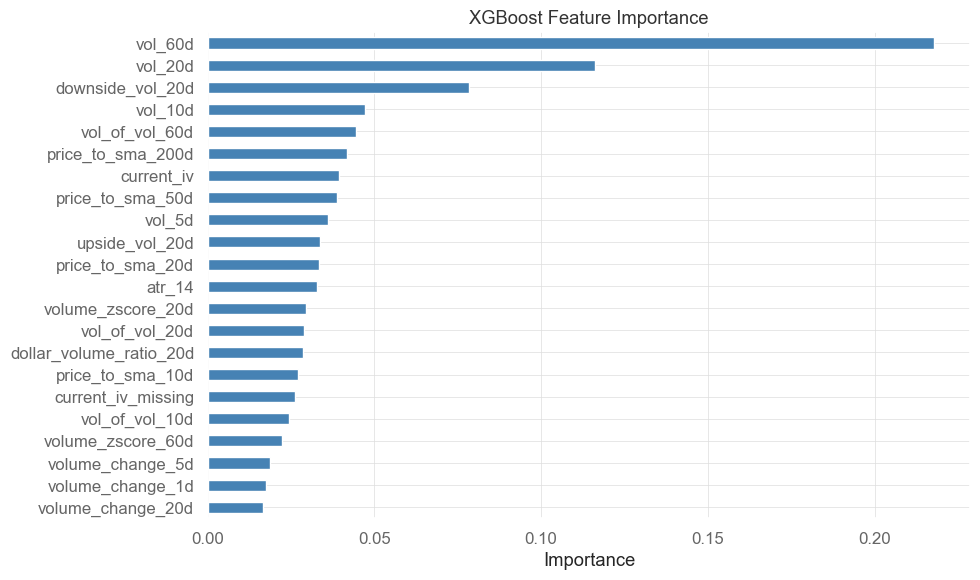

In [7]:
X_train = train_panel[TILT_FEATURE_NAMES]
y_train = train_panel['quintile']
X_val = val_panel[TILT_FEATURE_NAMES]
y_val = val_panel['quintile']

xgb_model = xgb.XGBClassifier(
    objective='multi:softprob',
    num_class=5,
    n_estimators=600,
    max_depth=4,
    learning_rate=0.02,
    subsample=0.75,
    colsample_bytree=0.75,
    min_child_weight=20,
    reg_lambda=3.0,
    reg_alpha=0.5,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
    eval_metric='mlogloss',
    early_stopping_rounds=40,
)

xgb_model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
val_pred = xgb_model.predict(X_val)
val_proba = xgb_model.predict_proba(X_val)
val_accuracy = accuracy_score(y_val, val_pred)
val_log_loss = log_loss(y_val, val_proba, labels=[0, 1, 2, 3, 4])

print('Validation accuracy:', round(val_accuracy, 4))
print('Validation log loss:', round(val_log_loss, 4))
print('Naive five-class accuracy:', 0.2)
print('Best iteration:', getattr(xgb_model, 'best_iteration', None))

importance = pd.Series(xgb_model.feature_importances_, index=TILT_FEATURE_NAMES).sort_values(ascending=False)
display(importance.to_frame('importance'))

fig, ax = plt.subplots(figsize=(10, 6))
importance.sort_values().plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost Feature Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 6. Fama-French 5-Factor Data

Daily FF5 factors are aligned to stock returns. Each rebalance uses only rows strictly before that rebalance date.

In [8]:
ff_start = prices['date'].min().date().isoformat()
ff_end = prices['date'].max().date().isoformat()
print('Downloading FF5 daily factors:', ff_start, '->', ff_end)

ff5_raw = pdr.DataReader('F-F_Research_Data_5_Factors_2x3_daily', 'famafrench', start=ff_start, end=ff_end)[0]
ff5 = ff5_raw / 100.0
ff5.index = pd.to_datetime(ff5.index)
factors = ff5[FACTOR_COLS].copy()
rf = ff5['RF'].copy()

common_factor_dates = returns_wide.index.intersection(factors.index)
print('FF5 rows:', len(factors))
print('Common return/factor dates:', len(common_factor_dates))
display(ff5.tail())

FF5 rows: 3018
Common return/factor dates: 3017


,Mkt-RF,SMB,HML,RMW,CMA,RF
Date,,,,,,
2025-12-24,0.0029,0.0007,0.0001,-0.0004,0.0023,0.0002
2025-12-26,-0.0006,-0.0021,0.0009,0.0057,0.0024,0.0002
2025-12-29,-0.0041,-0.0015,0.0006,0.0032,0.0002,0.0002
2025-12-30,-0.0020,-0.0051,0.0031,0.0032,0.0013,0.0002
2025-12-31,-0.0076,0.0006,-0.0010,-0.0008,-0.0005,0.0002


## 7. Risk Model And Optimization Helpers

These helpers keep the rolling loop readable. Betas use exponentially weighted least squares. Factor and residual covariance use Ledoit-Wolf shrinkage when there are enough observations. Intercepts are shrunk toward their cross-sectional mean and stored for diagnostics.

In [9]:
def exponential_sample_weights(n: int, halflife: float) -> np.ndarray:
    ages = np.arange(n - 1, -1, -1, dtype=float)
    weights = 0.5 ** (ages / float(halflife))
    return weights / weights.mean()


def weighted_factor_regression(y: np.ndarray, X: np.ndarray, weights: np.ndarray):
    X_design = np.column_stack([np.ones(len(X)), X])
    sqrt_w = np.sqrt(weights)
    beta, *_ = np.linalg.lstsq(X_design * sqrt_w[:, None], y * sqrt_w, rcond=None)
    fitted = X_design @ beta
    residuals = y - fitted
    return float(beta[0]), beta[1:].astype(float), residuals.astype(float)


def nearest_psd(matrix: np.ndarray, jitter: float = 1e-8) -> np.ndarray:
    sym = (matrix + matrix.T) / 2.0
    min_eig = float(np.linalg.eigvalsh(sym).min())
    if min_eig < jitter:
        sym = sym + np.eye(sym.shape[0]) * (abs(min_eig) + jitter)
    return sym


def estimate_ew_ff5_covariance(rebalance_date: pd.Timestamp):
    eligible_dates = common_factor_dates[common_factor_dates < pd.Timestamp(rebalance_date)]
    window_dates = eligible_dates[-FF_WINDOW:]
    if len(window_dates) < MIN_FACTOR_OBS:
        raise ValueError(f'Not enough factor observations before {rebalance_date}: {len(window_dates)}')

    window_returns = returns_wide.loc[window_dates, portfolio_tickers]
    window_factors = factors.loc[window_dates, FACTOR_COLS]
    window_rf = rf.loc[window_dates]
    X_all = window_factors.to_numpy(dtype=float)

    beta_rows = {}
    intercepts = {}
    residual_series = {}
    residual_vars = {}

    for ticker in portfolio_tickers:
        y_raw = window_returns[ticker] - window_rf
        valid = y_raw.notna() & window_factors.notna().all(axis=1) & window_rf.notna()
        if int(valid.sum()) < MIN_FACTOR_OBS:
            continue
        y = y_raw.loc[valid].to_numpy(dtype=float)
        X = window_factors.loc[valid, FACTOR_COLS].to_numpy(dtype=float)
        sample_weights = exponential_sample_weights(len(y), EW_HALFLIFE)
        intercept, beta, residuals = weighted_factor_regression(y, X, sample_weights)
        beta_rows[ticker] = beta
        intercepts[ticker] = intercept
        residual_series[ticker] = pd.Series(residuals, index=window_factors.loc[valid].index)
        residual_vars[ticker] = float(np.average(residuals ** 2, weights=sample_weights))

    fitted_tickers = list(beta_rows.keys())
    if len(fitted_tickers) < max(8, int(1.0 / MAX_WEIGHT) + 1):
        raise ValueError(f'Only {len(fitted_tickers)} tickers fitted before {rebalance_date}')

    B = np.vstack([beta_rows[ticker] for ticker in fitted_tickers])
    factor_lw = LedoitWolf().fit(window_factors.loc[:, FACTOR_COLS].dropna().to_numpy(dtype=float))
    F = factor_lw.covariance_

    residual_frame = pd.DataFrame(residual_series).loc[:, fitted_tickers]
    residual_centered = residual_frame - residual_frame.mean(skipna=True)
    residual_for_lw = residual_centered.fillna(0.0)

    residual_shrinkage = 1.0
    if residual_for_lw.shape[0] >= 20 and residual_for_lw.shape[1] >= 2:
        residual_lw = LedoitWolf().fit(residual_for_lw.to_numpy(dtype=float))
        E = residual_lw.covariance_
        residual_shrinkage = float(residual_lw.shrinkage_)
    else:
        E = np.diag([residual_vars[ticker] for ticker in fitted_tickers])

    Sigma = nearest_psd(B @ F @ B.T + E)

    intercept_series = pd.Series(intercepts, name='raw_intercept').loc[fitted_tickers]
    common_intercept = float(intercept_series.mean())
    shrunk_intercepts = ((1.0 - residual_shrinkage) * intercept_series) + (residual_shrinkage * common_intercept)
    beta_df = pd.DataFrame(B, index=fitted_tickers, columns=FACTOR_COLS)
    beta_df['raw_intercept'] = intercept_series
    beta_df['shrunk_intercept'] = shrunk_intercepts
    beta_df['residual_var'] = pd.Series(residual_vars).loc[fitted_tickers]

    diagnostics = {
        'rebalance_date': pd.Timestamp(rebalance_date),
        'window_start': pd.Timestamp(window_dates.min()),
        'window_end': pd.Timestamp(window_dates.max()),
        'n_obs': int(len(window_dates)),
        'n_tickers': int(len(fitted_tickers)),
        'factor_shrinkage': float(factor_lw.shrinkage_),
        'residual_shrinkage': residual_shrinkage,
        'min_eigenvalue': float(np.linalg.eigvalsh(Sigma).min()),
    }
    return fitted_tickers, Sigma, beta_df, diagnostics


def solve_min_variance_weights(tickers, Sigma: np.ndarray) -> pd.Series:
    n = len(tickers)
    w = cp.Variable(n)
    problem = cp.Problem(
        cp.Minimize(cp.quad_form(w, cp.psd_wrap(Sigma))),
        [cp.sum(w) == 1.0, w >= MIN_WEIGHT, w <= MAX_WEIGHT],
    )
    for solver in ['CLARABEL', 'OSQP', 'SCS']:
        try:
            problem.solve(solver=solver, verbose=False)
        except Exception:
            continue
        if problem.status in ('optimal', 'optimal_inaccurate') and w.value is not None:
            weights = pd.Series(np.asarray(w.value).reshape(-1), index=tickers, dtype=float).clip(MIN_WEIGHT, MAX_WEIGHT)
            weights = weights / weights.sum()
            return weights
    raise RuntimeError(f'Min-var optimization failed: {problem.status}')


def project_long_only_capped_weights(raw_weights: pd.Series) -> pd.Series:
    tickers = list(raw_weights.index)
    raw = raw_weights.to_numpy(dtype=float)
    n = len(raw)
    w = cp.Variable(n)
    problem = cp.Problem(
        cp.Minimize(cp.sum_squares(w - raw)),
        [cp.sum(w) == 1.0, w >= MIN_WEIGHT, w <= MAX_WEIGHT],
    )
    for solver in ['OSQP', 'CLARABEL', 'SCS']:
        try:
            problem.solve(solver=solver, verbose=False)
        except Exception:
            continue
        if problem.status in ('optimal', 'optimal_inaccurate') and w.value is not None:
            weights = pd.Series(np.asarray(w.value).reshape(-1), index=tickers, dtype=float).clip(MIN_WEIGHT, MAX_WEIGHT)
            weights = weights / weights.sum()
            return weights
    clipped = raw_weights.clip(MIN_WEIGHT, MAX_WEIGHT)
    return clipped / clipped.sum()


def expand_weight_series(weight_series: pd.Series, all_tickers: list[str]) -> pd.Series:
    expanded = pd.Series(0.0, index=all_tickers, dtype=float)
    expanded.loc[weight_series.index] = weight_series.astype(float)
    return expanded

## 8. Rolling 10-Day Rebalance Loop

Each rebalance date uses only factor/return data and feature snapshots strictly before that date. The tilted portfolio is projected back to long-only, fully invested, capped weights.

In [10]:
test_dates = pd.DatetimeIndex(adj_close.loc[test_start:test_end].index.unique()).sort_values()
rebalance_dates = test_dates[::REBALANCE_EVERY_DAYS]
print('Test trading dates:', len(test_dates))
print('Rebalance dates:', len(rebalance_dates))
print('First rebalance:', rebalance_dates[0])
print('Last rebalance:', rebalance_dates[-1])

feature_by_date = {pd.Timestamp(date): frame.copy() for date, frame in model_features.groupby('date', sort=True)}
available_feature_dates = pd.DatetimeIndex(sorted(feature_by_date.keys()))

minvar_rows = []
tilted_rows = []
xgb_rows = []
delta_rows = []
diagnostics_rows = []
last_beta_df = None

for idx, rebalance_date in enumerate(rebalance_dates, start=1):
    fitted_tickers, Sigma, beta_df, diagnostics = estimate_ew_ff5_covariance(rebalance_date)
    w_minvar = solve_min_variance_weights(fitted_tickers, Sigma)

    feature_pos = available_feature_dates.searchsorted(pd.Timestamp(rebalance_date), side='left') - 1
    if feature_pos < 0:
        raise ValueError(f'No feature snapshot before {rebalance_date}')
    signal_date = available_feature_dates[feature_pos]
    snapshot = feature_by_date[signal_date]
    snapshot = snapshot.loc[snapshot['ticker'].isin(fitted_tickers)].copy()

    proba = xgb_model.predict_proba(snapshot[TILT_FEATURE_NAMES])
    top_q_prob = pd.Series(proba[:, 4], index=snapshot['ticker'], name='top_quintile_probability')
    signal = top_q_prob.reindex(fitted_tickers).fillna(top_q_prob.mean())
    signal = signal - signal.mean()

    if float(signal.abs().sum()) > 0.0:
        delta = signal / signal.abs().sum() * TILT_ALPHA
    else:
        delta = signal * 0.0

    raw_tilted = w_minvar.add(delta, fill_value=0.0)
    w_tilted = project_long_only_capped_weights(raw_tilted)

    positive_scores = top_q_prob.reindex(fitted_tickers).clip(lower=0.0).fillna(0.0)
    if float(positive_scores.sum()) > 0.0:
        w_xgb = positive_scores / positive_scores.sum()
    else:
        w_xgb = pd.Series(1.0 / len(fitted_tickers), index=fitted_tickers)

    minvar_row = expand_weight_series(w_minvar, portfolio_tickers)
    tilted_row = expand_weight_series(w_tilted, portfolio_tickers)
    xgb_row = expand_weight_series(w_xgb, portfolio_tickers)
    delta_row = expand_weight_series(w_tilted - w_minvar, portfolio_tickers)

    minvar_row.name = pd.Timestamp(rebalance_date)
    tilted_row.name = pd.Timestamp(rebalance_date)
    xgb_row.name = pd.Timestamp(rebalance_date)
    delta_row.name = pd.Timestamp(rebalance_date)

    minvar_rows.append(minvar_row)
    tilted_rows.append(tilted_row)
    xgb_rows.append(xgb_row)
    delta_rows.append(delta_row)
    diagnostics_rows.append({**diagnostics, 'signal_date': pd.Timestamp(signal_date)})
    last_beta_df = beta_df

    if idx % 10 == 0 or idx == len(rebalance_dates):
        print(f'Processed {idx}/{len(rebalance_dates)} rebalances through {pd.Timestamp(rebalance_date).date()}')

minvar_weights = pd.DataFrame(minvar_rows)
tilted_weights = pd.DataFrame(tilted_rows)
xgb_weights = pd.DataFrame(xgb_rows)
tilt_deltas = pd.DataFrame(delta_rows)
risk_diagnostics = pd.DataFrame(diagnostics_rows)

minvar_weights.index.name = 'date'
tilted_weights.index.name = 'date'
xgb_weights.index.name = 'date'
tilt_deltas.index.name = 'date'

# Remove columns that are zero across every generated view, then validate row sums.
combined_abs_exposure = minvar_weights.abs().add(tilted_weights.abs(), fill_value=0.0).add(xgb_weights.abs(), fill_value=0.0)
active_columns = combined_abs_exposure.columns[(combined_abs_exposure.sum(axis=0) > 0.0)]
minvar_weights = minvar_weights.loc[:, active_columns]
tilted_weights = tilted_weights.loc[:, active_columns]
xgb_weights = xgb_weights.loc[:, active_columns]
tilt_deltas = tilt_deltas.loc[:, active_columns]

minvar_weights = validate_weights_frame(minvar_weights, dataset_name=DATASET_NAME, repo_root=repo_root)
tilted_weights = validate_weights_frame(tilted_weights, dataset_name=DATASET_NAME, repo_root=repo_root)
xgb_weights = validate_weights_frame(xgb_weights, dataset_name=DATASET_NAME, repo_root=repo_root)

print('Min-var weights shape:', minvar_weights.shape)
print('Tilted weights shape:', tilted_weights.shape)
print('Max tilted row-sum error:', float((tilted_weights.sum(axis=1) - 1.0).abs().max()))
print('Max single-name weight:', float(tilted_weights.max().max()))
display(risk_diagnostics.tail())

Test trading dates: 1003
Rebalance dates: 101
First rebalance: 2022-01-03 00:00:00
Last rebalance: 2025-12-29 00:00:00
Processed 10/101 rebalances through 2022-05-12
Processed 20/101 rebalances through 2022-10-05
Processed 30/101 rebalances through 2023-03-01
Processed 40/101 rebalances through 2023-07-25
Processed 50/101 rebalances through 2023-12-14
Processed 60/101 rebalances through 2024-05-09
Processed 70/101 rebalances through 2024-10-02
Processed 80/101 rebalances through 2025-02-27
Processed 90/101 rebalances through 2025-07-23
Processed 100/101 rebalances through 2025-12-12
Processed 101/101 rebalances through 2025-12-29
Min-var weights shape: (101, 501)
Tilted weights shape: (101, 501)
Max tilted row-sum error: 8.881784197001252e-16
Max single-name weight: 0.12203427927803728


,rebalance_date,window_start,window_end,n_obs,n_tickers,factor_shrinkage,residual_shrinkage,min_eigenvalue,signal_date
96,2025-10-30,2024-10-28,2025-10-29,252,501,0.158105,0.307726,0.000103,2025-10-29
97,2025-11-13,2024-11-11,2025-11-12,252,501,0.150592,0.301457,0.000099,2025-11-12
98,2025-11-28,2024-11-25,2025-11-26,252,501,0.144365,0.300887,0.000097,2025-11-26
99,2025-12-12,2024-12-10,2025-12-11,252,501,0.145741,0.302186,0.000098,2025-12-11
100,2025-12-29,2024-12-24,2025-12-26,252,501,0.149482,0.301327,0.000097,2025-12-26


## 9. Inspect Final Optimal Portfolio Weights

The final row of the tilted weights frame is the final optimal portfolio weight vector produced by this notebook.

Final rebalance date: 2025-12-29
Final weight sum: 0.9999999999999999
Final active names: 146

Top final optimal weights:
CME      0.0609
CBOE     0.0562
MO       0.0528
MSFT     0.0462
KR       0.0420
ED       0.0407
COR      0.0401
LMT      0.0377
DUK      0.0328
GOOGL    0.0328
XOM      0.0323
GOOG     0.0314
JNJ      0.0277
CNP      0.0269
KO       0.0264
NOC      0.0260
VTR      0.0225
PEP      0.0224
CF       0.0177
UPS      0.0161
COST     0.0160
TJX      0.0157
AEP      0.0152
DG       0.0144
JBHT     0.0144
TTWO     0.0138
AXON     0.0125
WMB      0.0116
GIS      0.0115
TAP      0.0113

Largest positive tilts:
PSKY    0.00008
MU      0.00009
GNRC    0.00009
INTC    0.00009
COHR    0.00010
VRT     0.00010
COIN    0.00011
MRNA    0.00012
TER     0.00012
AMD     0.00013
ARE     0.00013
HOOD    0.00013
WDC     0.00013
SMCI    0.00015
STX     0.00018

Largest negative tilts:
CME    -0.00013
EA     -0.00013
TJX    -0.00012
CBOE   -0.00012
MSFT   -0.00012
JNJ    -0.00012
COR    -0.00

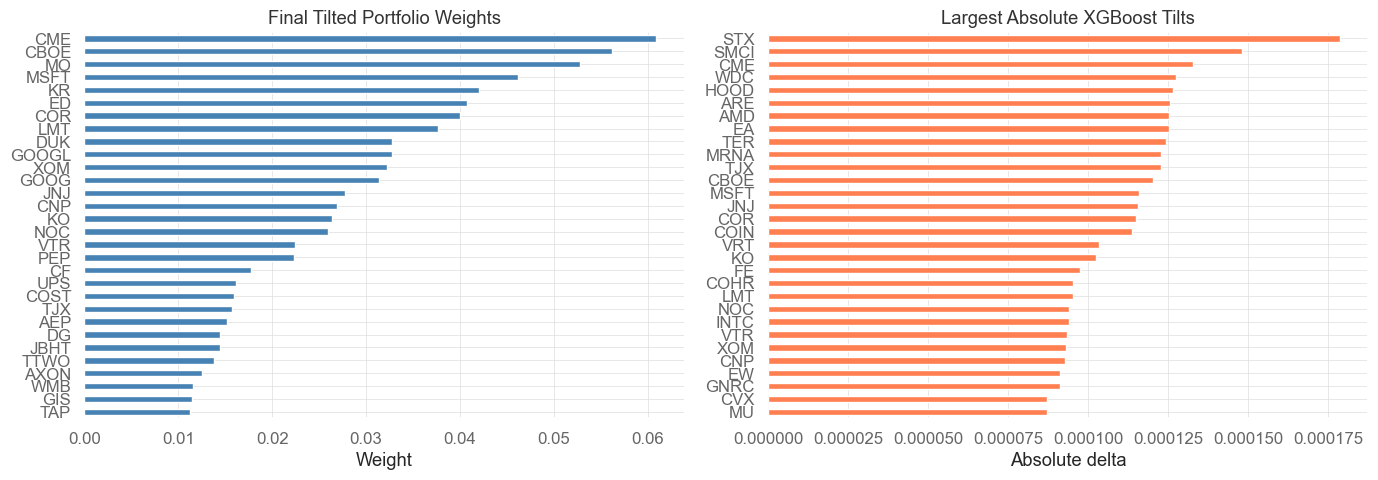

In [11]:
final_rebalance_date = tilted_weights.index.max()
final_optimal_weights = tilted_weights.loc[final_rebalance_date].sort_values(ascending=False)
final_minvar_weights = minvar_weights.loc[final_rebalance_date]
final_delta = (tilted_weights.loc[final_rebalance_date] - minvar_weights.loc[final_rebalance_date]).sort_values()

print('Final rebalance date:', final_rebalance_date.date())
print('Final weight sum:', final_optimal_weights.sum())
print('Final active names:', int((final_optimal_weights > 0).sum()))
print('\nTop final optimal weights:')
print(final_optimal_weights[final_optimal_weights > 0].head(30).round(4).to_string())

print('\nLargest positive tilts:')
print(final_delta.tail(15).round(5).to_string())

print('\nLargest negative tilts:')
print(final_delta.head(15).round(5).to_string())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
final_optimal_weights[final_optimal_weights > 0].head(30).sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Final Tilted Portfolio Weights')
axes[0].set_xlabel('Weight')
final_delta.abs().sort_values(ascending=False).head(30).sort_values().plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Largest Absolute XGBoost Tilts')
axes[1].set_xlabel('Absolute delta')
plt.tight_layout()
plt.show()

## 10. Portfolio Objects And Backtest

Both the pure rolling minimum-variance baseline and the XGBoost-tilted strategy are backtested through the shared toolkit wrapper.

In [12]:
def prepare_backtest_weight_frame(weights: pd.DataFrame) -> pd.DataFrame:
    prepared = weights.reindex(columns=portfolio_tickers, fill_value=0.0).astype(float)
    prepared = prepared.clip(lower=0.0, upper=MAX_WEIGHT)
    row_sums = prepared.sum(axis=1)
    if (row_sums <= 0.0).any():
        bad_dates = row_sums.loc[row_sums <= 0.0].index.tolist()
        raise ValueError(f'Cannot normalize zero-exposure weight rows: {bad_dates[:5]}')
    prepared = prepared.div(row_sums, axis=0)

    # Absorb tiny floating-point residuals into the largest position in each row so validation
    # and the toolkit-created equal-weight benchmark both see clean, fully invested rows.
    for date_value in prepared.index:
        residual = 1.0 - float(prepared.loc[date_value].sum())
        if abs(residual) <= 1e-12:
            continue
        target_ticker = prepared.loc[date_value].idxmax()
        prepared.loc[date_value, target_ticker] += residual

    return validate_weights_frame(prepared, dataset_name=DATASET_NAME, repo_root=repo_root)


minvar_weights_for_backtest = prepare_backtest_weight_frame(minvar_weights)
tilted_weights_for_backtest = prepare_backtest_weight_frame(tilted_weights)

portfolio_minvar = PortfolioWeights(
    weights=minvar_weights_for_backtest,
    dataset_name=DATASET_NAME,
    strategy_name=MINVAR_MODEL_NAME,
    metadata={
        'type': 'rolling_minvar',
        'factor_model': 'ew_ff5',
        'prediction_horizon_days': PREDICTION_HORIZON_DAYS,
        'rebalance_every_days': REBALANCE_EVERY_DAYS,
        'ff_window': FF_WINDOW,
        'ew_halflife': EW_HALFLIFE,
    },
)

portfolio_tilted = PortfolioWeights(
    weights=tilted_weights_for_backtest,
    dataset_name=DATASET_NAME,
    strategy_name=MODEL_NAME,
    metadata={
        'type': 'rolling_minvar_xgb_tilt',
        'factor_model': 'ew_ff5',
        'prediction_horizon_days': PREDICTION_HORIZON_DAYS,
        'rebalance_every_days': REBALANCE_EVERY_DAYS,
        'ff_window': FF_WINDOW,
        'ew_halflife': EW_HALFLIFE,
        'tilt_alpha': TILT_ALPHA,
        'iv_source': 'current_yfinance_option_chain_static_by_ticker',
    },
)

print('Min-var backtest row-sum max error:', float((portfolio_minvar.weights.sum(axis=1) - 1.0).abs().max()))
print('Tilted backtest row-sum max error:', float((portfolio_tilted.weights.sum(axis=1) - 1.0).abs().max()))
print('Backtest ticker columns:', len(portfolio_tilted.weights.columns), 'of', len(portfolio_tickers))

result_minvar = backtest_weights(DATASET_NAME, portfolio_minvar, repo_root=repo_root)
result_tilted = backtest_weights(DATASET_NAME, portfolio_tilted, repo_root=repo_root)

metrics_minvar = build_metrics(result_minvar)
metrics_tilted = build_metrics(result_tilted)

artifact_paths_minvar = write_backtest_artifacts(result_minvar, OUTPUT_DIR / 'minvar')
artifact_paths_tilted = write_backtest_artifacts(result_tilted, OUTPUT_DIR / 'tilted')

metrics_df = pd.DataFrame({'Min-Var EW FF5': metrics_minvar, 'Min-Var + XGB Tilt': metrics_tilted}).T
print('Test-period metrics:')
display(metrics_df)
print('Tilted QuantStats report:', artifact_paths_tilted['quantstats_report'])

Min-var backtest row-sum max error: 6.661338147750939e-16
Tilted backtest row-sum max error: 6.661338147750939e-16
Backtest ticker columns: 502 of 502
Test-period metrics:


,evaluation_years,evaluation_trading_days,total_return,annual_return,annual_volatility,sharpe,sortino,max_drawdown,calmar,average_turnover,benchmark_total_return,benchmark_annual_return,benchmark_annual_volatility,benchmark_sharpe,benchmark_max_drawdown,excess_return_vs_benchmark,annual_excess_return_vs_benchmark,sharpe_vs_benchmark
Min-Var EW FF5,3.991786,1003.0,0.371276,0.082310,0.112826,0.729531,1.025807,-0.152043,0.541360,0.175905,0.507582,0.108312,0.179691,0.602767,-0.244964,-0.136306,-0.026002,0.126765
Min-Var + XGB Tilt,3.991786,1003.0,0.376721,0.083385,0.113087,0.737354,1.036598,-0.152337,0.547373,0.176289,0.507582,0.108312,0.179691,0.602767,-0.244964,-0.130861,-0.024926,0.134587


Tilted QuantStats report: /Users/eamonnavin/Portfolio-Optimization-Lib/runs/minvar_wk3/tilted/quantstats.html


## 11. Backtest Plots

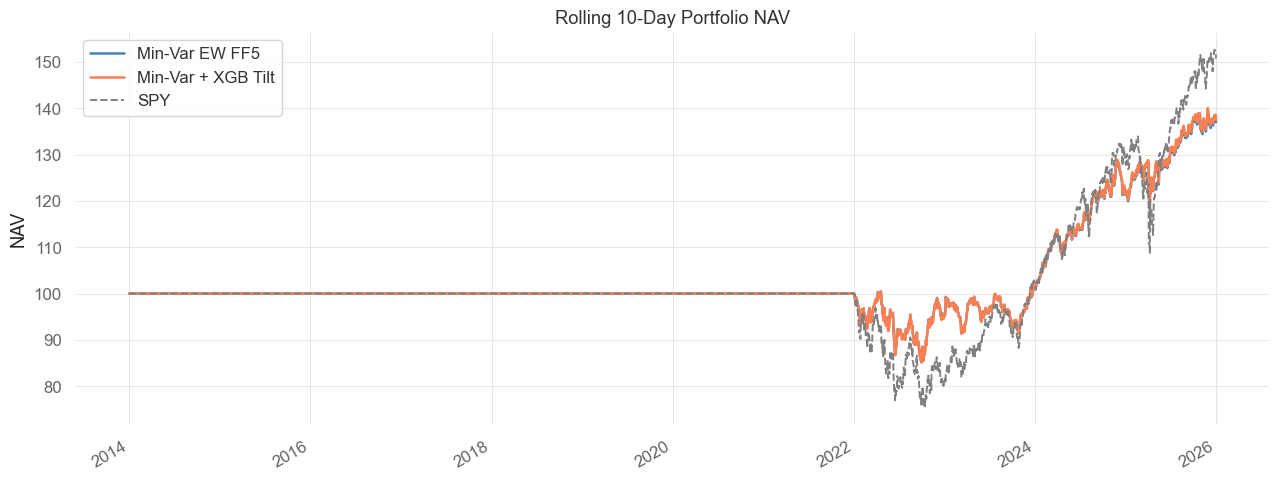

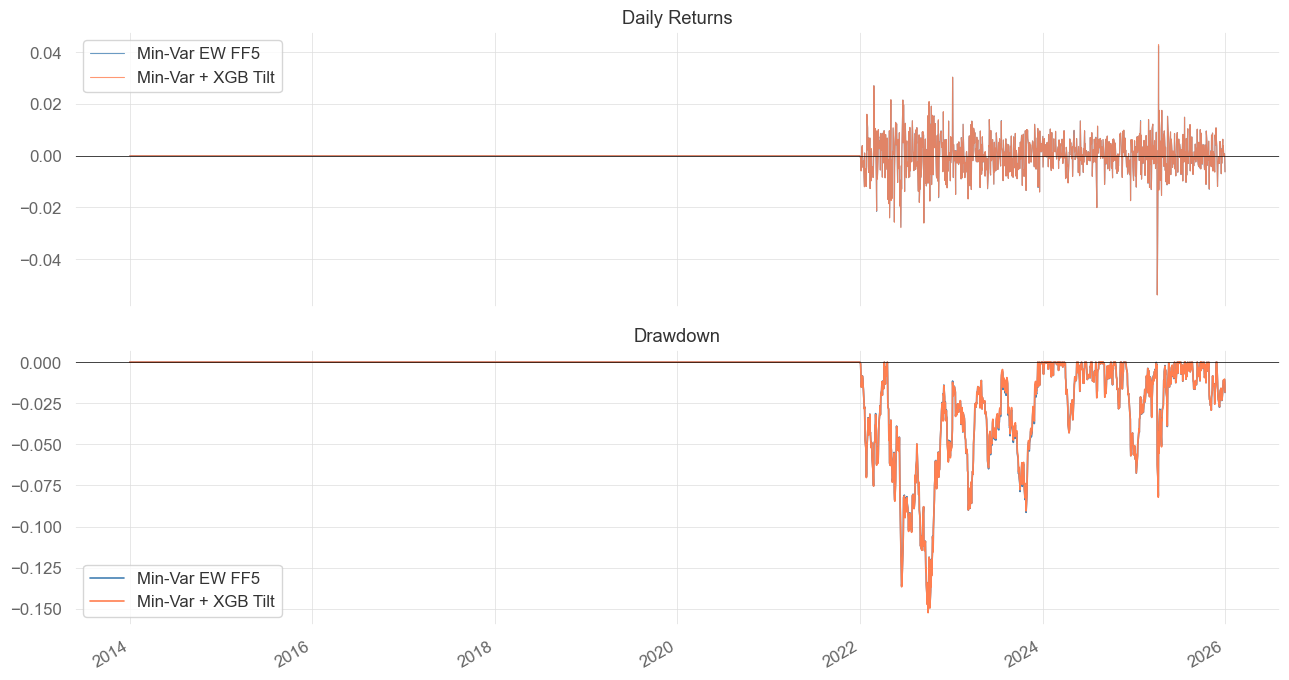

In [13]:
fig, ax = plt.subplots(figsize=(13, 5))
result_minvar.nav.rename('Min-Var EW FF5').plot(ax=ax, color='steelblue', linewidth=1.8)
result_tilted.nav.rename('Min-Var + XGB Tilt').plot(ax=ax, color='coral', linewidth=1.8)
if 'SPY' in result_tilted.benchmark_returns.columns:
    spy_nav = (1.0 + result_tilted.benchmark_returns['SPY']).cumprod() * result_tilted.nav.iloc[0]
    spy_nav.rename('SPY').plot(ax=ax, linestyle='--', color='gray', linewidth=1.4)
ax.set_title('Rolling 10-Day Portfolio NAV')
ax.set_ylabel('NAV')
ax.legend()
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for result, label, color in [
    (result_minvar, 'Min-Var EW FF5', 'steelblue'),
    (result_tilted, 'Min-Var + XGB Tilt', 'coral'),
]:
    drawdown = result.nav / result.nav.cummax() - 1.0
    result.returns.rename(label).plot(ax=axes[0], color=color, alpha=0.8, linewidth=0.8)
    drawdown.rename(label).plot(ax=axes[1], color=color, linewidth=1.2)
axes[0].set_title('Daily Returns')
axes[0].axhline(0, color='black', linewidth=0.5)
axes[0].legend()
axes[1].set_title('Drawdown')
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].legend()
plt.tight_layout()
plt.show()

## 12. Save Model And Log To MLflow

The MLflow run logs the tilted portfolio, backtest artifacts, XGBoost JSON model, and the configuration needed to understand the run.

In [14]:
xgb_model.save_model(MODEL_ARTIFACT_PATH)

mlflow_layout = init_mlflow(repo_root)
print('MLflow tracking URI:', mlflow_layout['tracking_uri'])

with start_run(
    run_name=MODEL_NAME,
    dataset_name=DATASET_NAME,
    tags={
        'model_family': 'xgboost',
        'strategy_type': 'rolling_minvar_xgb_tilt',
        'factor_model': 'ew_ff5',
        'prediction_horizon_days': str(PREDICTION_HORIZON_DAYS),
        'rebalance_every_days': str(REBALANCE_EVERY_DAYS),
    },
    repo_root=repo_root,
):
    mlflow.log_params(
        {
            'dataset_name': DATASET_NAME,
            'prediction_horizon_days': PREDICTION_HORIZON_DAYS,
            'rebalance_every_days': REBALANCE_EVERY_DAYS,
            'ff_window': FF_WINDOW,
            'ew_halflife': EW_HALFLIFE,
            'tilt_alpha': TILT_ALPHA,
            'min_weight': MIN_WEIGHT,
            'max_weight': MAX_WEIGHT,
            'xgb_best_iteration': int(getattr(xgb_model, 'best_iteration', -1) or -1),
            'xgb_val_accuracy': float(val_accuracy),
            'xgb_val_log_loss': float(val_log_loss),
            'feature_count': len(TILT_FEATURE_NAMES),
            'feature_names': ','.join(TILT_FEATURE_NAMES),
            'iv_source': 'current_yfinance_option_chain_static_by_ticker',
            'iv_missing_count': int(iv_snapshot['current_iv_missing'].sum()),
            'rebalance_count': len(tilted_weights),
            'active_ticker_count': len(tilted_weights.columns),
        }
    )
    log_portfolio(portfolio_tilted)
    log_backtest(result_tilted)
    manifest = log_model_submission(
        {'model': MODEL_ARTIFACT_PATH},
        model_name=MODEL_NAME,
        model_family='xgboost',
        feature_names=TILT_FEATURE_NAMES,
        target=target_col,
        horizon=PREDICTION_HORIZON_DAYS,
        rebalance_frequency=f'every_{REBALANCE_EVERY_DAYS}_trading_days',
        preprocessing={
            'cross_sectional_rank_normalized': rank_normalized_features,
            'binary_features': ['current_iv_missing'],
            'iv_source': 'current_yfinance_option_chain_static_by_ticker',
        },
        model_config={
            'library': 'xgboost',
            'estimator': 'XGBClassifier',
            'objective': 'multi:softprob',
            'num_class': 5,
            'factor_model': 'ew_ff5',
            'ff_window': FF_WINDOW,
            'ew_halflife': EW_HALFLIFE,
            'tilt_alpha': TILT_ALPHA,
            'portfolio_builder': 'notebook_local_minvar_plus_centered_xgb_tilt',
        },
        source_files=[repo_root / 'MODELS' / 'Eamon' / 'minvar_wk3.ipynb'],
        notes='Rolling 10-day min-variance portfolio using EW FF5 betas and a small XGBoost top-quintile tilt.',
    )

print('Model artifact:', MODEL_ARTIFACT_PATH)
print('MLflow logging complete.')

MLflow tracking URI: https://adams-macbook-pro.tail5ddc35.ts.net
🏃 View run Eamon_Run4 at: https://adams-macbook-pro.tail5ddc35.ts.net/#/experiments/2/runs/9041062dc54b4f729d31d79edb922705
🧪 View experiment at: https://adams-macbook-pro.tail5ddc35.ts.net/#/experiments/2
Model artifact: /Users/eamonnavin/Portfolio-Optimization-Lib/runs/minvar_wk3/Eamon_Run4.json
MLflow logging complete.
